## **Pomocne moduly**

In [80]:
import itertools
import math
import numpy as np
import UQpy
from scipy.special import comb
from UQpy.distributions import Uniform,Normal, JointIndependent
from UQpy.surrogates.polynomial_chaos import TotalDegreeBasis, LeastSquareRegression
from UQpy.sensitivity import PceSensitivity
from UQpy.sampling import MonteCarloSampling
from sklearn.metrics import mean_squared_error, r2_score
import time  
import scipy as sp
import random
import matplotlib.pyplot as plt

import SAPCE

import sys
import os
from UQpy.sampling import LatinHypercubeSampling
from scipy.spatial import cKDTree

In [4]:

def root_mean_squared_error(y_true, y_pred, multioutput='uniform_average'):
    mse = mean_squared_error(y_true, y_pred, multioutput=multioutput)
    if isinstance(mse, np.ndarray):
        return np.sqrt(mse)
    return np.sqrt(mse)


Text(0.5, 0, '$n_{sim}$')

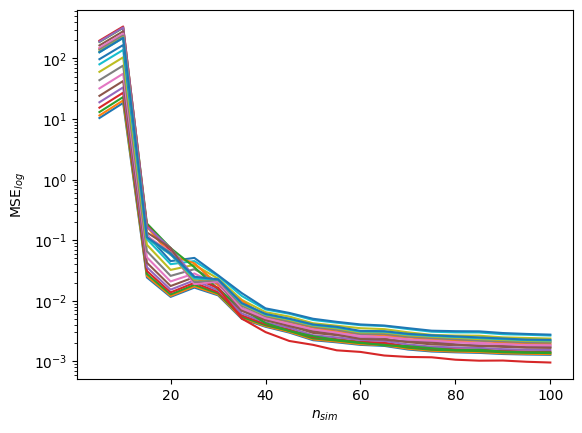

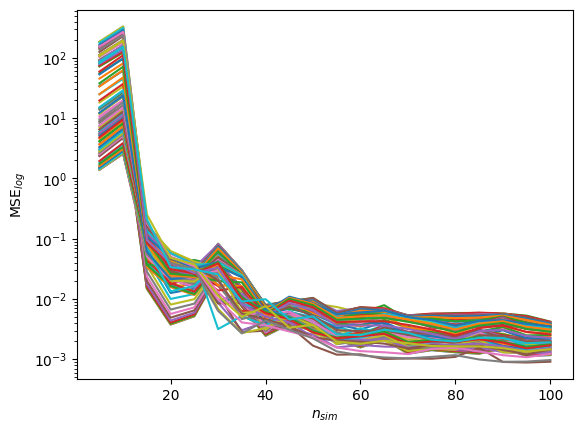

In [24]:
import sys, os
import pandas as pd

class SuppressOutput:
    def __enter__(self):
        self._original_stdout = sys.stdout
        self._original_stderr = sys.stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = self._original_stdout
        sys.stderr = self._original_stderr

data = pd.read_csv('Oakwood.csv', sep=';', header=0)
data_NVM= pd.read_csv('Oakwood_NVM.csv', sep=';', header=0)
names=data.columns.tolist()
names_NVM=data_NVM.columns.tolist()
data_array_NVM=data_NVM.to_numpy()

X=data_array_NVM[:,:12]
Y_all=data_array_NVM[:,12:]
Y_tunnel=data_array_NVM[:,12:23]
Y_surface=data_array_NVM[:,23:]
Y_all_NVM=data_array_NVM[:,12:]
Y_N=Y_all_NVM[:,:113]
Y_V=Y_all_NVM[:,113:226]
Y_M=Y_all_NVM[:,226:]

Y_all.shape
# Concrete parameters


dist_Ec=Normal(13,1)
dist_Relax=Uniform(30,40)

# Soil1
dist_S1_Erel=Uniform(2,1)
dist_S1_E50=Normal(65,5)
dist_S1_c=Normal(30,5)
dist_S1_theta=Normal(30,1)
dist_S1_ko=Uniform(0.6,0.5)
# Soil2
dist_S1_Erel=Uniform(2,1)
dist_S1_E50=Normal(130,10)
dist_S1_c=Normal(5,1)
dist_S1_theta=Normal(42,1)
dist_S1_ko=Uniform(0.45,0.2)

marg = [dist_Ec,dist_Relax, dist_S1_Erel, dist_S1_E50, dist_S1_c,dist_S1_theta,dist_S1_ko,dist_S1_Erel,dist_S1_E50,dist_S1_c,dist_S1_theta,dist_S1_ko]
joint = JointIndependent(marginals=marg)

errs_stat=[]
for s in range(50):
    errs=[]
    nsim=[]
    for i in range(1,21):
        nsim.append(5+5*i)
        rand_indices=random.sample(range(len(Y_all)), nsim[-1])
        xx_train=X[rand_indices,:]
        yy_train=Y_all[rand_indices,:]

        xx_val=np.delete(X, rand_indices)
        yy_val=np.delete(Y_all, rand_indices)

        with SuppressOutput():
            sapce = SAPCE.SensitivityAdaptivePCE(pdf=joint, exp_design_in=xx_train, exp_design_out=yy_train, max_partial_degree=10, num_inputs=12)
            sapce.construct_adaptive_basis(max_condition_number=1e3)
            sapce.construct_pruned_pce(cr=1e-8)

        errs.append(sapce.pce.validation_error(X,Y_all))

    errs_stat.append(errs)

errs_stat_array=np.array(errs_stat)
fig, ax = plt.subplots()
for i in range(21):
    ax.plot(nsim,np.mean(errs_stat_array[:,:,2+i],axis=0),label='sim {}'.format(i))
ax.set_yscale('log')
ax.set_ylabel('MSE$_{log}$')
ax.set_xlabel('$n_{sim}$')

errs_stat=[]
for s in range(1):
    errs=[]
    nsim=[]
    for i in range(1,21):
        nsim.append(5+5*i)
        rand_indices=random.sample(range(len(Y_all)), nsim[-1])
        xx_train=X[rand_indices,:]
        yy_train=Y_all_NVM[rand_indices,:]

        xx_val=np.delete(X, rand_indices)
        yy_val=np.delete(Y_all_NVM, rand_indices)

        with SuppressOutput():
            sapce = SAPCE.SensitivityAdaptivePCE(pdf=joint, exp_design_in=xx_train, exp_design_out=yy_train, max_partial_degree=10, num_inputs=12)
            sapce.construct_adaptive_basis(max_condition_number=1e3)
            sapce.construct_pruned_pce(cr=1e-8)

        errs.append(sapce.pce.validation_error(X,Y_all_NVM))

    errs_stat.append(errs)

errs_stat_array=np.array(errs_stat)
fig, ax = plt.subplots()
for i in range(len(yy_train)):
    ax.plot(nsim, np.mean(errs_stat_array[:, :, i], axis=0), label='sim {}'.format(i))
ax.set_yscale('log')
ax.set_ylabel('MSE$_{log}$')
ax.set_xlabel('$n_{sim}$')

In [6]:
sapce.pce.coefficients

array([[-1.29560876e+06, -1.29882996e+06, -1.30592791e+06, ...,
         1.92850736e+04,  1.75008004e+04,  1.64125145e+04],
       [-2.36233275e+04, -2.35046704e+04, -2.32152641e+04, ...,
        -3.64864067e+03, -3.63418404e+03, -3.62157620e+03],
       [-8.64038955e+03, -8.73992378e+03, -8.77903724e+03, ...,
         1.09734480e+03,  6.85816197e+02,  4.83702761e+02],
       ...,
       [-5.06251843e+01, -5.36903146e+01, -5.26252923e+01, ...,
        -1.67673727e+01, -1.97191998e+01, -2.06768721e+01],
       [-6.79002311e+00, -9.36851564e+00, -8.72980323e+00, ...,
        -2.41194876e+01, -2.66279071e+01, -2.69356233e+01],
       [ 2.03137247e+02,  1.99473618e+02,  1.95366163e+02, ...,
        -3.47834141e+01, -3.79583953e+01, -3.61150876e+01]])

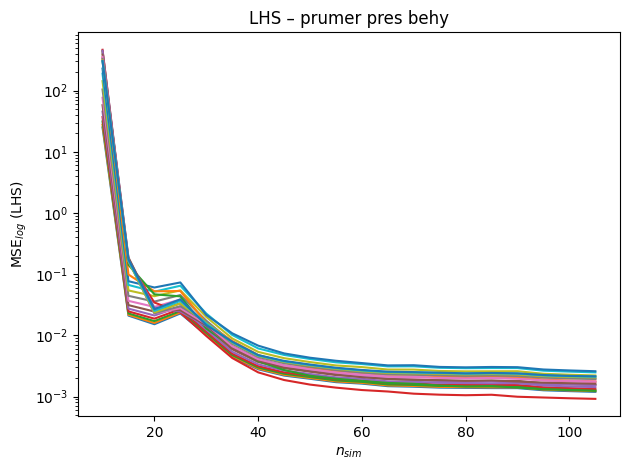

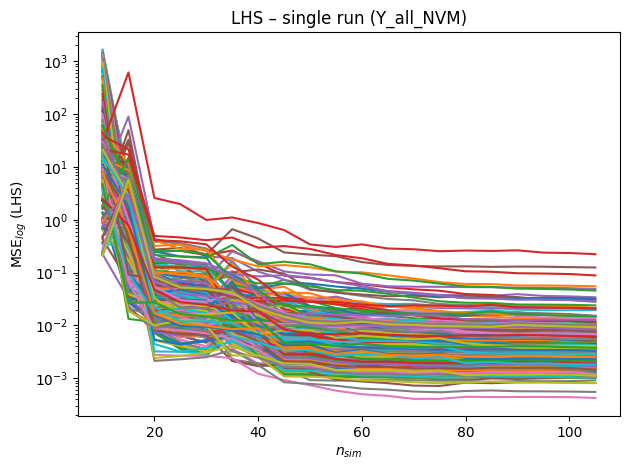

In [65]:


class Ticho: # potlač výpisy
    def __enter__(self):
        self._out = sys.stdout
        self._err = sys.stderr
        sys.stdout = open(os.devnull, "w")
        sys.stderr = open(os.devnull, "w")

    def __exit__(self, *a):
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = self._out
        sys.stderr = self._err


def vyber_lhs(X, dist, n, seed=None): # první výběr LHS
    if n > len(X):
        raise ValueError(f"n={n} je moc velke")

    marg = dist.marginals

    X_u = np.column_stack([marg[j].cdf(X[:, j]) for j in range(X.shape[1])]) # CDF databáze

    with Ticho():
        lhs = LatinHypercubeSampling(distributions=dist, nsamples=n, random_state=seed)

    lhs_u = np.column_stack([marg[j].cdf(lhs.samples[:, j]) for j in range(lhs.samples.shape[1])]) # CDF LHS vzorků

    strom = cKDTree(X_u)
    _, idx = strom.query(lhs_u, k=1) # nejbližší bod v databázi

    rng = np.random.default_rng(seed)
    vybrané = []
    použité = set()
    všechny = set(range(len(X)))

    for i in idx:
        i = int(i)
        if i not in použité:
            vybrané.append(i) # bod je volný
            použité.add(i)
        else:
            zbytek = list(všechny - použité)
            if not zbytek:
                break
            náhrada = int(rng.choice(zbytek)) # náhodná náhrada
            vybrané.append(náhrada)
            použité.add(náhrada)

    return np.array(vybrané, dtype=int)


def pridej_maximin(X_u, old_idx, kolik, kandidati, seed=None): # přidej body maximin
    if len(old_idx) == 0:
        raise ValueError("old_idx je prazdne")

    rng = np.random.default_rng(seed)
    vybrané = list(old_idx)
    použité = set(vybrané)

    kand = [int(c) for c in kandidati if int(c) not in použité]
    kand = list(dict.fromkeys(kand)) # odstraň duplikáty

    for _ in range(kolik):
        if kand:
            body = X_u[vybrané]
            nej_idx = None
            nej_dist = -1.0

            for c in kand:
                vzdál = np.linalg.norm(X_u[c] - body, axis=1)
                min_d = float(np.min(vzdál))
                if min_d > nej_dist: # hledáme maximum minima
                    nej_dist = min_d
                    nej_idx = c

            if nej_idx is not None:
                vybrané.append(nej_idx)
                použité.add(nej_idx)
                kand.remove(nej_idx)
                continue

        zbytek = list(set(range(len(X_u))) - použité)
        if not zbytek:
            break
        vybrané.append(int(rng.choice(zbytek))) # náhodný záložní bod
        použité.add(vybrané[-1])

    return np.array(vybrané, dtype=int)


marg = joint.marginals
X_u = np.column_stack([marg[j].cdf(X[:, j]) for j in range(X.shape[1])]) # CDF vstupů


chyby_lhs = [] # výsledky bloku 1

for s in range(50):
    ch = []
    ns = []
    idx = None

    for i in range(1, 21):
        n = 5 + 5 * i # 10, 15, ..., 105
        ns.append(n)

        if i == 1:
            idx = vyber_lhs(X, joint, n, seed=s * 100 + i) # první krok

        else:
            n_pool = max(50, 50)

            with Ticho():
                pool = LatinHypercubeSampling(distributions=joint, nsamples=n_pool, random_state=s * 1000 + i)

            pool_u = np.column_stack([marg[j].cdf(pool.samples[:, j]) for j in range(pool.samples.shape[1])])

            strom = cKDTree(X_u)
            _, kand = strom.query(pool_u, k=1) # kandidáti z poolu
            kand = list(dict.fromkeys(kand.tolist()))

            idx = pridej_maximin(X_u, idx.tolist(), 5, kand, seed=s * 100 + i)

        Xtr = X[idx, :]
        Ytr = Y_all[idx, :]

        with Ticho():
            model = SAPCE.SensitivityAdaptivePCE(
                pdf=joint,
                exp_design_in=Xtr,
                exp_design_out=Ytr,
                max_partial_degree=10,
                num_inputs=12,
            )
            model.construct_adaptive_basis(max_condition_number=1e3)
            model.construct_pruned_pce(cr=1e-8)

        err = model.pce.validation_error(X, Y_all) # validační chyba
        ch.append(err)

    chyby_lhs.append(ch)

lhs_arr = np.array(chyby_lhs) # shape: (50, 20, výstupy)

fig, ax = plt.subplots()
n_out = lhs_arr.shape[2]
for k in range(2, min(23, n_out)):
    ax.plot(ns, np.mean(lhs_arr[:, :, k], axis=0), label=f"sim {k - 2}")
ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$ (LHS)")
ax.set_xlabel("$n_{sim}$")
ax.set_title("LHS – průměr přes běhy")
plt.tight_layout()
plt.show()


chyby_lhs2 = [] # výsledky bloku 2

for s in range(1):
    ch = []
    ns = []
    idx = None

    for i in range(1, 21):
        n = 5 + 5 * i # 10, 15, ..., 105
        ns.append(n)

        if i == 1:
            idx = vyber_lhs(X, joint, n, seed=s * 100 + i)

        else:
            n_pool = max(50, 50)

            with Ticho():
                pool = LatinHypercubeSampling(distributions=joint, nsamples=n_pool, random_state=s * 1000 + i)

            pool_u = np.column_stack([marg[j].cdf(pool.samples[:, j]) for j in range(pool.samples.shape[1])])

            strom = cKDTree(X_u)
            _, kand = strom.query(pool_u, k=1)
            kand = list(dict.fromkeys(kand.tolist()))

            idx = pridej_maximin(X_u, idx.tolist(), 5, kand, seed=s * 100 + i)

        Xtr = X[idx, :]
        Ytr = Y_all_NVM[idx, :]

        with Ticho():
            model = SAPCE.SensitivityAdaptivePCE(
                pdf=joint,
                exp_design_in=Xtr,
                exp_design_out=Ytr,
                max_partial_degree=10,
                num_inputs=12,
            )
            model.construct_adaptive_basis(max_condition_number=1e3)
            model.construct_pruned_pce(cr=1e-8)

        err = model.pce.validation_error(X, Y_all_NVM)
        ch.append(err)

    chyby_lhs2.append(ch)

lhs2_arr = np.array(chyby_lhs2)

fig, ax = plt.subplots()
for i in range(lhs2_arr.shape[2]):
    ax.plot(ns, np.mean(lhs2_arr[:, :, i], axis=0), label=f"sim {i}")
ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$ (LHS)")
ax.set_xlabel("$n_{sim}$")
ax.set_title("LHS – single run (Y_all_NVM)")
plt.tight_layout()
plt.show()

Theta

In [ ]:
class Ticho:
    def __enter__(self):
        self._o = sys.stdout
        self._e = sys.stderr
        sys.stdout = open(os.devnull, "w")
        sys.stderr = open(os.devnull, "w")

    def __exit__(self, *a):
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = self._o
        sys.stderr = self._e
        return False  # potlačí výpisy třetích stran


MAX_STUPEN = 10   # maximální stupeň polynomu
N0         = 10   # počet bodů v počátečním designu
KROK       = 5    # bodů přidaných v každém kroku
N_KROKU    = 19   # kroků celkem → 100 přidaných bodů
N_MAX      = N0 + KROK * (N_KROKU - 1)  # celkový počet bodů
N_REP      = 50   # počet replikací (Blok 1)
SEED       = 0    # základní seed; replikace s dostane SEED + s*100


def priprav_pce(pce, Xtr, Ytr):
    """Z PCE sestaví objekt pro Theta-kritérium.
    Vybere nejvariabilnější výstup a nastaví koeficienty, vstupy a výstupy.   """
    col  = int(np.argmax(np.var(Ytr, axis=0)))  # index nejvariabilnějšího výstupu
    koef = pce.coefficients.copy()              # koeficienty tvaru (báze, výstupy)

    baze = copy.deepcopy(pce.polynomial_basis)  # báze převzata přímo z aktuálního PCE

    p = PolynomialChaosExpansion(
        polynomial_basis=baze,
        regression_method=LassoRegression()
    )
    p.coefficients               = koef[:, col].reshape(-1, 1)        # jeden vybraný výstup
    p.experimental_design_input  = Xtr.copy()                         # trénovací vstupy
    p.experimental_design_output = Ytr[:, col].reshape(-1, 1).copy()  # trénovací výstup

    return p


def theta_jeden(X, idx, p):
    """
    Theta-kritéria vybere jeden nový bod z kandidátní sady.    """
    pouzite  = set(idx.tolist())
    kand_idx = np.array([j for j in range(len(X)) if j not in pouzite])  # kandidáti mimo stávající design

    if len(kand_idx) == 0:
        return idx  # žádný kandidát → nic nepřidáme

    Xk  = X[kand_idx, :]
    th  = ThetaCriterionPCE(surrogates=[p])
    sel = th.run(existing_samples=X[idx, :], candidate_samples=Xk, nsamples=1)  # Theta vybere nejlepší bod
    sel = np.asarray(sel)

    if sel.ndim == 2 or (sel.ndim == 1 and sel.dtype.kind == 'f'):
        if sel.ndim == 1:
            sel = sel.reshape(1, -1)
        _, loc = cKDTree(Xk).query(sel, k=1)  # převedeme souřadnice zpět na index
        loc = int(loc.flatten()[0])
    else:
        loc = int(sel.flatten()[0])  # Theta vrátila přímo index

    if loc >= len(kand_idx):
        loc = 0  # pojistka proti přetečení indexu

    return np.append(idx, kand_idx[loc])


def pridej_theta(X, idx, p, k, rng):
    for _ in range(k):  # přidáváme vždy jen jeden bod najednou
        if len(set(range(len(X))) - set(idx.tolist())) == 0:
            break  # vyčerpány všechny kandidáti
        idx = theta_jeden(X, idx, p)
    return idx


joint0 = copy.deepcopy(joint)  # záloha pro reset mezi replikacemi
X0     = X.copy()
Yall0  = Y_all.copy()


chyby1 = []
nsim1  = []

for s in range(N_REP):
    print(f"[1] rep {s+1}/{N_REP}")

    X     = X0.copy()
    Y_all = Yall0.copy()
    jc    = copy.deepcopy(joint0)

    ch  = []
    ns  = []
    idx = None
    p   = None
    rng = np.random.default_rng(SEED + s * 100)

    for i in range(1, N_KROKU + 1):
        n = N0 + KROK * (i - 1)
        ns.append(n)

        if i == 1:
            idx = rng.choice(len(X), size=N0, replace=False)  # počáteční náhodný design
        else:
            idx = pridej_theta(X, idx, p, KROK, rng)  # Theta přidává body od 2. kroku

        Xtr = X[idx, :]
        Ytr = Y_all[idx, :]

        with Ticho():
            m = SAPCE.SensitivityAdaptivePCE(
                pdf=jc,
                exp_design_in=Xtr,
                exp_design_out=Ytr,
                max_partial_degree=MAX_STUPEN,
                num_inputs=12,
            )
            m.construct_adaptive_basis(max_condition_number=1e3)
            m.construct_pruned_pce(cr=1e-8)

        p = priprav_pce(m.pce, Xtr, Ytr)

        err = m.pce.validation_error(X, Y_all)  # MSE na celé sadě
        ch.append(err)
        print(f"  krok {i}/{N_KROKU} n={n} baze={m.pce.coefficients.shape[0]} MSE={np.mean(err):.4e}")

    chyby1.append(ch)
    if s == 0:
        nsim1 = ns

print("Blok 1 dokončen.")
arr1 = np.array(chyby1)

fig, ax = plt.subplots()
n_out = arr1.shape[2]
for k in range(2, min(23, n_out)):
    ax.plot(nsim1, np.mean(arr1[:, :, k], axis=0), label=f"sim {k-2}")
ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$ (Theta)")
ax.set_xlabel("$n_{sim}$")
ax.set_title("Theta – statistické replikace (Y_all)")
plt.tight_layout()
plt.show()



Ynvm0 = Y_all_NVM.copy()  # záloha NVM dat

chyby2 = []
nsim2  = []

for s in range(1):
    print("[2] single run")

    X         = X0.copy()
    Y_all_NVM = Ynvm0.copy()
    jc        = copy.deepcopy(joint0)

    ch  = []
    ns  = []
    idx = None
    p   = None
    rng = np.random.default_rng(SEED + s * 100)

    for i in range(1, N_KROKU + 1):
        n = N0 + KROK * (i - 1)
        ns.append(n)

        if i == 1:
            idx = rng.choice(len(X), size=N0, replace=False)  # počáteční náhodný design
        else:
            idx = pridej_theta(X, idx, p, KROK, rng)  # Theta přidává body od 2. kroku

        Xtr = X[idx, :]
        Ytr = Y_all_NVM[idx, :]

        with Ticho():
            m = SAPCE.SensitivityAdaptivePCE(
                pdf=jc,
                exp_design_in=Xtr,
                exp_design_out=Ytr,
                max_partial_degree=MAX_STUPEN,
                num_inputs=12,
            )
            m.construct_adaptive_basis(max_condition_number=1e3)
            m.construct_pruned_pce(cr=1e-8)

        p = priprav_pce(m.pce, Xtr, Ytr)

        err = m.pce.validation_error(X, Y_all_NVM)  # MSE na celé NVM sadě
        ch.append(err)
        print(f"  krok {i}/{N_KROKU} n={n} MSE={np.mean(err):.4e}")

    chyby2.append(ch)
    nsim2 = ns

print("Blok 2 dokončen.")
arr2 = np.array(chyby2)

fig, ax = plt.subplots()
for i in range(arr2.shape[2]):
    ax.plot(nsim2, np.mean(arr2[:, :, i], axis=0), label=f"sim {i}")
ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$ (Theta)")
ax.set_xlabel("$n_{sim}$")
ax.set_title("Theta – single run (Y_all_NVM)")
plt.tight_layout()
plt.show()

[1] rep 1/50
  krok 1/19 n=10 baze=13 MSE=4.3131e+01
  krok 2/19 n=15 baze=13 MSE=4.7235e-01
  krok 3/19 n=20 baze=17 MSE=3.0311e-01
  krok 4/19 n=25 baze=23 MSE=7.0457e-02
  krok 5/19 n=30 baze=28 MSE=6.7049e-01
  krok 6/19 n=35 baze=28 MSE=5.4316e-02
  krok 7/19 n=40 baze=28 MSE=4.4724e-02
  krok 8/19 n=45 baze=28 MSE=3.5080e-02
  krok 9/19 n=50 baze=36 MSE=5.0471e-02
  krok 10/19 n=55 baze=40 MSE=4.3543e-02
  krok 11/19 n=60 baze=37 MSE=5.0066e-02
  krok 12/19 n=65 baze=37 MSE=2.6023e-02
  krok 13/19 n=70 baze=36 MSE=1.4626e-02
  krok 14/19 n=75 baze=36 MSE=1.2596e-02
  krok 15/19 n=80 baze=45 MSE=1.3598e-02
  krok 16/19 n=85 baze=37 MSE=1.1014e-02
  krok 17/19 n=90 baze=44 MSE=9.9120e-03
  krok 18/19 n=95 baze=44 MSE=9.3840e-03
  krok 19/19 n=100 baze=37 MSE=8.7366e-03
[1] rep 2/50
  krok 1/19 n=10 baze=13 MSE=1.6060e+01
  krok 2/19 n=15 baze=13 MSE=3.3339e-01
  krok 3/19 n=20 baze=16 MSE=1.6138e-01
  krok 4/19 n=25 baze=23 MSE=1.5511e-01
  krok 5/19 n=30 baze=23 MSE=3.6356e-02
  k

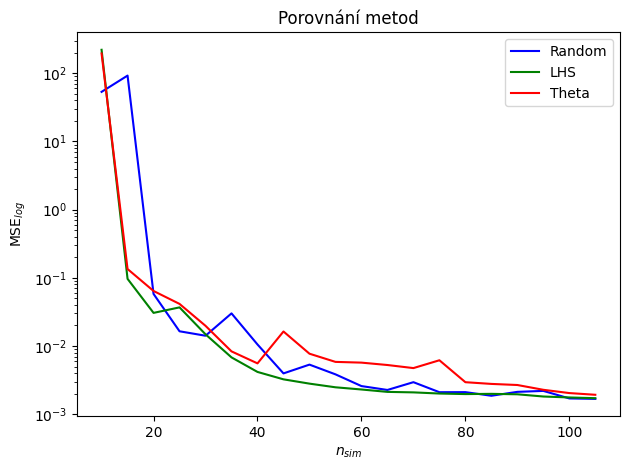

In [145]:
start_idx = 2 # začátek výstupů
end_idx   = min(start_idx + 21, errs_stat_theta_array.shape[2]) # konec výstupů

mean_random = np.mean(errs_stat_array      [:, :, start_idx:end_idx], axis=(0, 2)) # průměr random
mean_lhs    = np.mean(errs_stat_lhs_array  [:, :, start_idx:end_idx], axis=(0, 2)) # průměr LHS
mean_theta  = np.mean(errs_stat_theta_array[:, :, start_idx:end_idx], axis=(0, 2)) # průměr Theta

nsim_random = [10 + 5 * (i - 1) for i in range(1, 21)] # osa x random
nsim_lhs    = [10 + 5 * (i - 1) for i in range(1, 21)] # osa x LHS
nsim_theta  = [10 + 5 * (i - 1) for i in range(1, 21)] # osa x Theta

fig, ax = plt.subplots()
ax.plot(nsim_random, mean_random, label='Random', color='blue')
ax.plot(nsim_lhs,    mean_lhs,    label='LHS',    color='green')
ax.plot(nsim_theta,  mean_theta,  label='Theta',  color='red')
ax.set_yscale('log')
ax.set_ylabel('MSE$_{log}$')
ax.set_xlabel('$n_{sim}$')
ax.set_title('Porovnání metod')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:


# plt.rcParams['axes.linewidth'] = 0.5
# plt.rcParams['text.usetex']=True
# #plt.rc('text.latex', preamble=r'\usepackage[bitstream-charter]{mathdesign}')
# plt.rcParams['font.size'] = 10
# plt.rcParams['xtick.major.width'] = 0.5
# plt.rcParams['ytick.major.width'] = 0.5
# # Times, Palatino, New Century Schoolbook, Bookman, Computer Modern Roman
# plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman']}) 

# import matplotlib
# matplotlib.use('pgf')
# plt.rcParams["pgf.texsystem"] = "xelatex"
# plt.rcParams["pgf.rcfonts"] = False

# preamble = r'''\usepackage[utf8]{inputenc} %unicode support
# \usepackage[czech]{babel}
# \usepackage[T1]{fontenc}
# \DeclareMathAlphabet{\pazocal}{OMS}{zplm}{m}{n}
# \usepackage{calrsfs}
# \usepackage{amsmath}
# \usepackage{bm}
# \usepackage[bitstream-charter]{mathdesign}
# '''
# plt.rc('text.latex', preamble=preamble)
# plt.rcParams["pgf.preamble"] = preamble

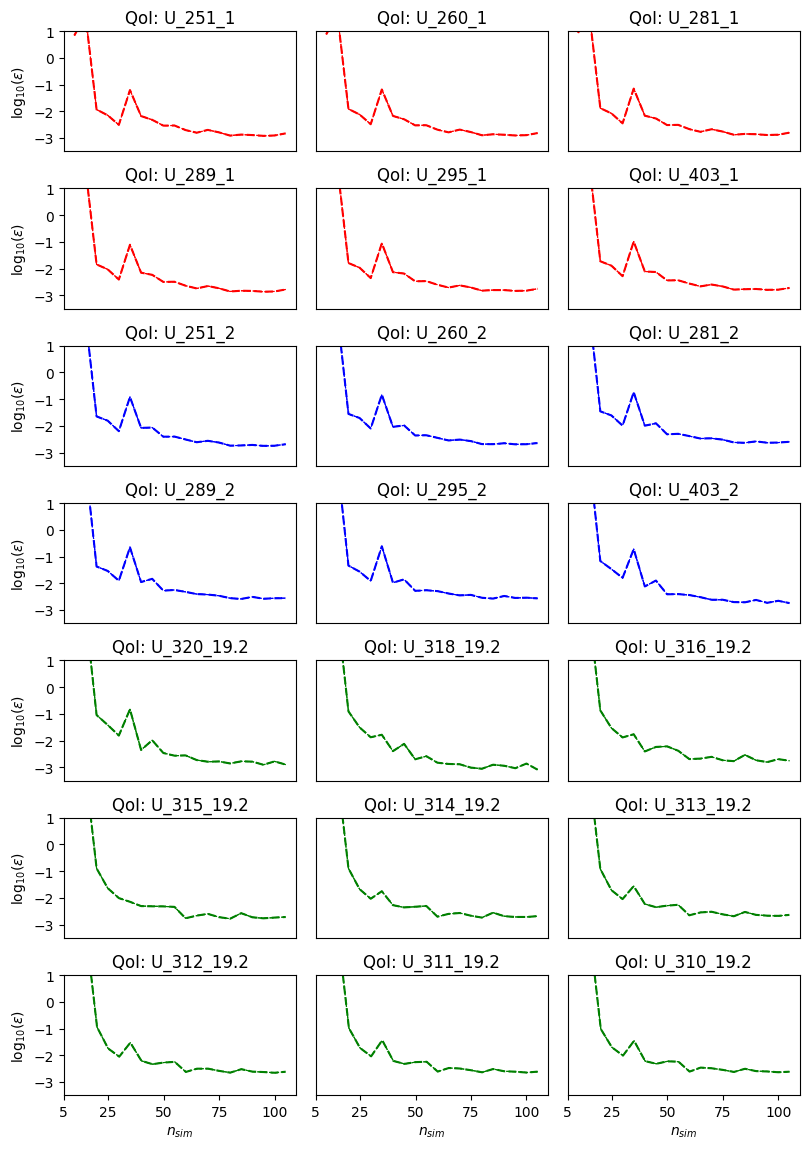

In [11]:
def logplot (vals):
    vals=np.log10(vals)
    delta=(np.std(np.array(vals)))
    means=(np.mean(np.array(vals)))
    maxy=(np.mean(np.array(vals))+delta)
    miny=(np.mean(np.array(vals))-delta)
    if means<-10:
        means=-10
        maxy=-10
        miny=-10
    return means,maxy,miny



sims=len(nsim)
fig, axis = plt.subplots(7,3,figsize=(8.2,11.6))

j=0
for ax in axis.flatten():
    means=np.zeros(sims)
    maxs=np.zeros(sims)
    mins=np.zeros(sims)

    for i in range(sims):
        means[i],maxs[i],mins[i]=logplot(errs_stat_array[:,i,j+2])
        
    ax.set_title('QoI: {}'.format(names[12+j]))  
    ax.set_ylim(-3.5,1)
    ax.set_yticks([])
    ax.set_xticks([])
    
    if j<6:
        color='red'
        color_hex=(1,0,0,0.1)
        
    elif j<12:
        color='blue'
        color_hex=(0,0,1,0.1)
        
    else:
        color='green'
        color_hex=(0,1,0,0.1)
    ax.plot(nsim,means,'--',c=color)
    ax.plot(nsim,mins,'--',c=color,linewidth=0.8)
    ax.plot(nsim,maxs,'--',c=color,linewidth=0.8)
    ax.fill_between(nsim, mins, maxs, facecolor=color_hex)

    j=j+1
    


j=0
for ax in axis.flatten():
    if j%3==0:
        ax.set_yticks([1,0,-1,-2,-3])
        ax.set_ylabel('log$_{10}$($\epsilon$)')
    j=j+1
    
    if j>18:
        ax.set_xticks([5,25,50,75,100])
        ax.set_xlabel('$n_{sim}$')
    
fig.tight_layout()
# fig.savefig('results_displacements.pdf')

In [12]:
names[12+j]

'U_308_19.2'